In [62]:
# !pip3 install scikit-learn matplotlib numpy

In [116]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt 
import numpy as np 
import random 
%matplotlib inline

In [117]:
np.random.seed(1337)
random.seed(1337)

In [118]:
X, Y = make_moons(n_samples = 100, noise = 0.1)

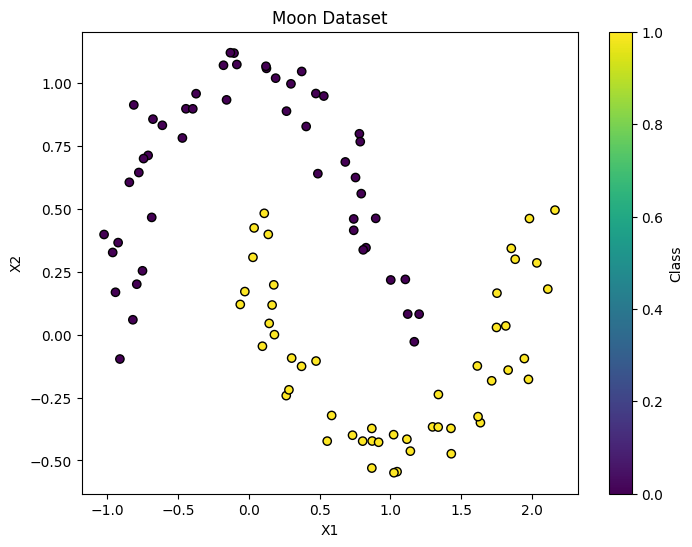

In [119]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', edgecolors='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Moon Dataset')
plt.colorbar(label='Class')
plt.show()

In [120]:
X.dtype

dtype('float64')

In [121]:
type(X)

numpy.ndarray

In [122]:
print(X[:10])

[[ 1.12211461  0.08147717]
 [-0.81882941  0.05879006]
 [ 1.61370966 -0.1246459 ]
 [-0.92300918  0.3652289 ]
 [ 0.14385146  0.04438005]
 [ 0.16447247  0.11738346]
 [ 1.33877062 -0.23800993]
 [ 0.87114861 -0.42271759]
 [ 1.83129946 -0.14104383]
 [ 0.4875712   0.63909283]]


In [123]:
print(Y[:10])

[0 0 1 0 1 1 1 1 1 0]


In [124]:
X.dtype, X[:2], X.shape

(dtype('float64'),
 array([[ 1.12211461,  0.08147717],
        [-0.81882941,  0.05879006]]),
 (100, 2))

In [125]:
Y.dtype, Y[:2], Y.shape

(dtype('int64'), array([0, 0]), (100,))

In [126]:
# x min ? max ? 
X.min(axis = 0), X.max(axis = 0)

(array([-1.02219391, -0.5486393 ]), array([2.16205598, 1.1193894 ]))

In [127]:
# 1st column min value: -1.02 
# 1st column max value: 2.16
# 2nd column min value: -0.54
# 2nd column max value: 1.119

In [128]:
Y.min(), Y.max()

(np.int64(0), np.int64(1))

In [129]:
xs = X.tolist()

In [130]:
len(xs)

100

In [131]:
# for x in xs: 
#     print(x)
#     print(len(x))
#     break
print(len(xs[0]))

2


In [132]:
ys = Y.tolist()

In [133]:
len(ys)

100

In [134]:
type(xs), type(ys)

(list, list)

In [135]:
import torch

In [136]:
xs = torch.tensor(xs)

In [137]:
print(xs[:10])

tensor([[ 1.1221,  0.0815],
        [-0.8188,  0.0588],
        [ 1.6137, -0.1246],
        [-0.9230,  0.3652],
        [ 0.1439,  0.0444],
        [ 0.1645,  0.1174],
        [ 1.3388, -0.2380],
        [ 0.8711, -0.4227],
        [ 1.8313, -0.1410],
        [ 0.4876,  0.6391]])


In [138]:
xs.dtype, xs.shape

(torch.float32, torch.Size([100, 2]))

In [139]:
ys = torch.tensor(ys)

In [140]:
ys.dtype, ys.shape

(torch.int64, torch.Size([100]))

In [141]:
import torch 
import torch.nn as nn

In [142]:
m = nn.Sequential(
    nn.Linear(2, 16), 
    nn.ReLU(), 
    nn.Linear(16, 16), 
    nn.ReLU(), 
    nn.Linear(16, 1)
)

In [143]:
ypreds = m(xs)

In [144]:
ypreds.dtype, ypreds.shape

(torch.float32, torch.Size([100, 1]))

In [145]:
import pprint
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

tensor([[0.0523],
        [0.0040],
        [0.0628],
        [0.0113],
        [0.0343],
        [0.0376],
        [0.0466],
        [0.0348],
        [0.0802],
        [0.0724]], grad_fn=<SliceBackward0>)
tensor([0, 0, 1, 0, 1, 1, 1, 1, 1, 0])


In [146]:
ys.shape, ypreds.shape

(torch.Size([100]), torch.Size([100, 1]))

In [147]:
ys = ys.view(ys.shape[0], 1)

In [148]:
import pprint
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

tensor([[0.0523],
        [0.0040],
        [0.0628],
        [0.0113],
        [0.0343],
        [0.0376],
        [0.0466],
        [0.0348],
        [0.0802],
        [0.0724]], grad_fn=<SliceBackward0>)
tensor([[0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0]])


In [149]:
ys.shape, ypreds.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

In [150]:
loss = (ypreds - ys).pow(2).mean()

In [151]:
loss

tensor(0.4476, grad_fn=<MeanBackward0>)

In [152]:
m.zero_grad()

In [153]:
loss.backward()

In [154]:
for p in m.parameters(): 
    p.data += (-0.0001) * p.grad

In [155]:
ypreds = m(xs) 
loss = (ypreds - ys).pow(2).mean()
loss

tensor(0.4474, grad_fn=<MeanBackward0>)

In [156]:
epoch = 10000
for i in range(epoch): 
    ypreds = m(xs)
    loss = (ypreds - ys).pow(2).mean()
    if i % 10 == 0: 
        print(f"epoch {i}, loss: {loss}")
    m.zero_grad()  
    loss.backward() 
    with torch.no_grad(): 
        for p in m.parameters():
            p.data += (-0.001) * p.grad


epoch 0, loss: 0.4474228024482727
epoch 10, loss: 0.4325816035270691
epoch 20, loss: 0.4187696874141693
epoch 30, loss: 0.40572652220726013
epoch 40, loss: 0.3934290409088135
epoch 50, loss: 0.38174423575401306
epoch 60, loss: 0.37079113721847534
epoch 70, loss: 0.360416054725647
epoch 80, loss: 0.3506219983100891
epoch 90, loss: 0.3413998782634735
epoch 100, loss: 0.33272767066955566
epoch 110, loss: 0.32457298040390015
epoch 120, loss: 0.31689879298210144
epoch 130, loss: 0.3097052276134491
epoch 140, loss: 0.30295947194099426
epoch 150, loss: 0.29662182927131653
epoch 160, loss: 0.2906986176967621
epoch 170, loss: 0.2851155400276184
epoch 180, loss: 0.27986207604408264
epoch 190, loss: 0.2749277353286743
epoch 200, loss: 0.2702975869178772
epoch 210, loss: 0.26592543721199036
epoch 220, loss: 0.2618025243282318
epoch 230, loss: 0.25794026255607605
epoch 240, loss: 0.25432148575782776
epoch 250, loss: 0.25091230869293213
epoch 260, loss: 0.2477092146873474
epoch 270, loss: 0.24470120

In [111]:
# import pickle 
# # weights dump after training
# weights = [p.data for p in m.parameters()] 
# with open("model_weights_torch_without_batch.pkl", 'wb') as f: 
#     pickle.dump(weights, f)


In [157]:
# load model weights 
import pickle
with open("model_weights_torch_without_batch.pkl", 'rb') as f: 
    weights = pickle.load(f)

In [158]:
for p, w in zip(m.parameters(), weights): 
    p.data = w

In [159]:
ypreds = [m(x)for x in xs]
loss = sum((ypred - y) ** 2 for ypred, y in zip(ypreds, ys))


In [160]:
print(loss)

tensor([0.0588], grad_fn=<AddBackward0>)


In [161]:
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

[tensor([-0.0134], grad_fn=<ViewBackward0>),
 tensor([-0.0144], grad_fn=<ViewBackward0>),
 tensor([0.9883], grad_fn=<ViewBackward0>),
 tensor([-0.0099], grad_fn=<ViewBackward0>),
 tensor([0.9918], grad_fn=<ViewBackward0>),
 tensor([0.9996], grad_fn=<ViewBackward0>),
 tensor([0.9219], grad_fn=<ViewBackward0>),
 tensor([0.9827], grad_fn=<ViewBackward0>),
 tensor([0.9931], grad_fn=<ViewBackward0>),
 tensor([0.0056], grad_fn=<ViewBackward0>)]
tensor([[0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0]])


(-1.6130505552165426, 1.8869494447834574)

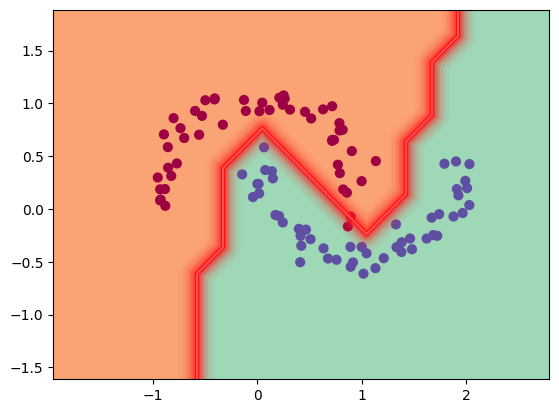

In [164]:
xs2, ys2 = make_moons(n_samples = 100, noise = 0.1)
h = 0.25
x_min, x_max = xs2[:, 0].min() - 1, xs2[:, 0].max() + 1
y_min, y_max = xs2[:, 1].min() - 1, xs2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = torch.tensor(Xmesh, dtype=torch.float32)
scores = m(inputs)
Z = (scores.data > 0.5).numpy()
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

# Add glowing neon red decision boundary with enhanced glow
# Outer glow layers (more layers, wider spread, brighter colors)
for lw, alpha in [(25, 0.05), (20, 0.08), (16, 0.12), (12, 0.18), (9, 0.25), (6, 0.35), (4, 0.5)]:
    plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff2222'], linewidths=lw, alpha=alpha)

# Core bright red line
contour = plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff0000'], linewidths=2.5)
# Inner bright highlight
plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff6666'], linewidths=1.5, alpha=0.8)

plt.scatter(xs2[:, 0], xs2[:, 1], c=ys2, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())